# **"The Daily Buzz" Weather Prediction Project**

# **Questions**

## **1. My views about the Problem Statement?**

The goal is to build a machine learning model to predict if it will rain the next day in Sydney based on historical weather data.

The process involves cleaning and transforming the data, handling categorical variables and ouliers, and trying out different classification models to identify the one with the best performance.

Ultimately, the aim is to find a model that provides accurate predictions for rainfall and highlights which weather features are most important in making these predictions.

## **2. What will be my approach to solving this Task?**

My approach would be:

* **Data Formatting and Cleaning:** I'll start by handling missing values, converting categorical fields into numerical values, and addressing any outliers. I'll also create dummy variables for any multi-class categorical variables.

* **Exploratory Data Analysis (EDA):** I'll visualize the relationships between features and the target variable to identify key features and understand their impact on rainfall predictions.

* **Model Training:** I'll begin with basic models like Logistic Regression and then move on to more complex methods such as LDA, KNN, and various ensemble techniques like Decision Trees, Random Forest, Gradient Boosting, AdaBoost, and XGBoost.

* **Model Comparison:** I'll evaluate all models based on metrics such as accuracy, confusion matrix, F1 score, and roc auc score to determine their performance.

* **Final Model Selection:** At last, I'll select the best-performing model based on these metrics and ensure it provides reliable predictions.

## **3. What were the available ML model options I had to perform this Task?**

Here are some of the available options:

* **Logistic Regression:** Simple and interpretable, used as a baseline for classification tasks.

* **Linear Discriminant Analysis (LDA):** Useful for dimensionality reduction and classification.

* **K-Nearest Neighbors (KNN):** A non-parametric method that classifies based on the closest neighbors.

* **Decision Tree Classifier:** Provides clear interpretability and visual representation.

* **Bagging Classifier:** Reduces variance by combining predictions from multiple Decision Trees.

* **Random Forest Classifier:** An ensemble method that improves accuracy by using multiple decision trees with random feature subsets.

* **Gradient Boosting Classifier:** Builds trees sequentially to correct errors from previous models.

* **AdaBoost:** Focuses on correcting errors by adjusting weights on misclassified instances.

* **XGBoost:** An optimized version of gradient boosting known for its high performance and efficiency.

For this project, I have utilized all these methods to evaluate and predict rainfall accurately.

## **4. Which model's performance is best and what could be the possible reason for that?**

**Tuned XGBoost** achieved the highest accuracy of **85.030%** and performed the best.

*Some reasons for this performance could be:*

**XGBoost's Effectiveness:** It uses advanced boosting techniques and regularization, handling complex patterns and interactions well.

**Basic Models:** Random Forest had the highest accuracy among basic models, showing strong performance with its ensemble approach.

**Limitations:** Computational constraints and dataset size might have limited the full potential of some models, like XGBoost.

Overall, XGBoost performed best due to its sophisticated algorithm and tuning, though ensemble methods generally showed strong results.

## **5. What steps can I take to improve the selected model's performance even further?**

To further improve the model's performance, I could:

* **Feature Engineering:** Create new features from existing ones to capture more information, such as interactions between weather variables.

* **Advanced Hyperparameter Tuning:** Use more comprehensive grid search or RandomizedSearchCV for better parameter optimization.

* **Ensemble Stacking:** Combine XGBoost with other models like Random Forest or Gradient Boosting to leverage their strengths.

* **Cross-Validation:** Apply advanced cross-validation techniques like stratified K-Folds to ensure more reliable results.

These steps are straightforward yet effective in enhancing model performance.

# **Importing Libraries**

In [1]:
# Importing numpy for numerical operations and pandas for data manipulation and analysis
import numpy as np
import pandas as pd

# Importing Seaborn and Matplotlib for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# **Loading the Dataset**

In [2]:
# Loading the given dataset using pandas read_excel function
df = pd.read_excel("/content/sydney_rain prediction.xlsx", header = 0)

In [3]:
# Viewing the top 5 rows for df dataset
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-02-01,Sydney,19.5,22.4,15.6,6.2,0.0,92.0,84.0,1017.6,1017.4,8.0,8.0,20.7,20.9,Yes,Yes
1,2008-02-02,Sydney,19.5,25.6,6.0,3.4,2.7,83.0,73.0,1017.9,1016.4,7.0,7.0,22.4,24.8,Yes,Yes
2,2008-02-03,Sydney,21.6,24.5,6.6,2.4,0.1,88.0,86.0,1016.7,1015.6,7.0,8.0,23.5,23.0,Yes,Yes
3,2008-02-04,Sydney,20.2,22.8,18.8,2.2,0.0,83.0,90.0,1014.2,1011.8,8.0,8.0,21.4,20.9,Yes,Yes
4,2008-02-05,Sydney,19.7,25.7,77.4,NaN,0.0,88.0,74.0,1008.3,1004.8,8.0,8.0,22.5,25.5,Yes,Yes


# **Formatting & Cleaning the Data**

### **Checking for Null values**

In [4]:
# Viewing the summary of the dataset which includes information like count of non-null values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3337 entries, 0 to 3336
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          3337 non-null   datetime64[ns]
 1   Location      3337 non-null   object        
 2   MinTemp       3334 non-null   float64       
 3   MaxTemp       3335 non-null   float64       
 4   Rainfall      3331 non-null   float64       
 5   Evaporation   3286 non-null   float64       
 6   Sunshine      3321 non-null   float64       
 7   Humidity9am   3323 non-null   float64       
 8   Humidity3pm   3324 non-null   float64       
 9   Pressure9am   3317 non-null   float64       
 10  Pressure3pm   3318 non-null   float64       
 11  Cloud9am      2771 non-null   float64       
 12  Cloud3pm      2776 non-null   float64       
 13  Temp9am       3333 non-null   float64       
 14  Temp3pm       3333 non-null   float64       
 15  RainToday     3331 non-null   object  

The dataset contains null values. We will handle missing values by imputing numeric columns with the *mean* and categorical columns with the *mode*.

In [5]:
# Selecting all the numeric columns and filling null values with mean
for i in df.select_dtypes(include = "number").columns:
  df[i].fillna(df[i].mean(), inplace=True)

In [6]:
# Filling null values in RainToday column with mode of the column
df["RainToday"] = df["RainToday"].fillna(df["RainToday"].mode())

In [7]:
# Checking to see if all the null values are removed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3337 entries, 0 to 3336
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          3337 non-null   datetime64[ns]
 1   Location      3337 non-null   object        
 2   MinTemp       3337 non-null   float64       
 3   MaxTemp       3337 non-null   float64       
 4   Rainfall      3337 non-null   float64       
 5   Evaporation   3337 non-null   float64       
 6   Sunshine      3337 non-null   float64       
 7   Humidity9am   3337 non-null   float64       
 8   Humidity3pm   3337 non-null   float64       
 9   Pressure9am   3337 non-null   float64       
 10  Pressure3pm   3337 non-null   float64       
 11  Cloud9am      3337 non-null   float64       
 12  Cloud3pm      3337 non-null   float64       
 13  Temp9am       3337 non-null   float64       
 14  Temp3pm       3337 non-null   float64       
 15  RainToday     3331 non-null   object  

### **Variable Transformation**

In [8]:
# Converting the Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Extracting the month and creating a new column with numeric values for the month
df["Month"] = df["Date"].dt.month

In [9]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,2008-02-01,Sydney,19.5,22.4,15.6,6.200000,0.0,92.0,84.0,1017.6,1017.4,8.0,8.0,20.7,20.9,Yes,Yes,2
1,2008-02-02,Sydney,19.5,25.6,6.0,3.400000,2.7,83.0,73.0,1017.9,1016.4,7.0,7.0,22.4,24.8,Yes,Yes,2
2,2008-02-03,Sydney,21.6,24.5,6.6,2.400000,0.1,88.0,86.0,1016.7,1015.6,7.0,8.0,23.5,23.0,Yes,Yes,2
3,2008-02-04,Sydney,20.2,22.8,18.8,2.200000,0.0,83.0,90.0,1014.2,1011.8,8.0,8.0,21.4,20.9,Yes,Yes,2
4,2008-02-05,Sydney,19.7,25.7,77.4,5.187432,0.0,88.0,74.0,1008.3,1004.8,8.0,8.0,22.5,25.5,Yes,Yes,2


### **Creating Dummy Variables**

In [10]:
# Since we know that the number of dummy variables should be one less than the number of categories, so we'll remove the extra column using drop_first parameter.
df = pd.get_dummies(df, columns = ["RainToday", "RainTomorrow"], drop_first = True, dtype = int)

# Renaming columns for better readability and consistency
df.rename(columns = {"RainToday_Yes" : "RainToday", "RainTomorrow_Yes" : "RainTomorrow"}, inplace = True)

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month,RainToday,RainTomorrow
0,2008-02-01,Sydney,19.5,22.4,15.6,6.200000,0.0,92.0,84.0,1017.6,1017.4,8.0,8.0,20.7,20.9,2,1,1
1,2008-02-02,Sydney,19.5,25.6,6.0,3.400000,2.7,83.0,73.0,1017.9,1016.4,7.0,7.0,22.4,24.8,2,1,1
2,2008-02-03,Sydney,21.6,24.5,6.6,2.400000,0.1,88.0,86.0,1016.7,1015.6,7.0,8.0,23.5,23.0,2,1,1
3,2008-02-04,Sydney,20.2,22.8,18.8,2.200000,0.0,83.0,90.0,1014.2,1011.8,8.0,8.0,21.4,20.9,2,1,1
4,2008-02-05,Sydney,19.7,25.7,77.4,5.187432,0.0,88.0,74.0,1008.3,1004.8,8.0,8.0,22.5,25.5,2,1,1


**Dropping Unwanted Columns**

In [11]:
df = df.drop(columns = ["Date", "Location"])

In [12]:
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month,RainToday,RainTomorrow
0,19.5,22.4,15.6,6.200000,0.0,92.0,84.0,1017.6,1017.4,8.0,8.0,20.7,20.9,2,1,1
1,19.5,25.6,6.0,3.400000,2.7,83.0,73.0,1017.9,1016.4,7.0,7.0,22.4,24.8,2,1,1
2,21.6,24.5,6.6,2.400000,0.1,88.0,86.0,1016.7,1015.6,7.0,8.0,23.5,23.0,2,1,1
3,20.2,22.8,18.8,2.200000,0.0,83.0,90.0,1014.2,1011.8,8.0,8.0,21.4,20.9,2,1,1
4,19.7,25.7,77.4,5.187432,0.0,88.0,74.0,1008.3,1004.8,8.0,8.0,22.5,25.5,2,1,1


# **Performing EDD**

In [13]:
# Looking at the summary statistics for the numerical columns to check for any outliers
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month,RainToday,RainTomorrow
count,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000
mean,14.865057,23.002339,3.330231,5.187432,7.179374,68.229010,54.699158,1018.346156,1016.018774,4.181523,4.218660,17.819742,21.533333,6.413545,0.259515,0.259215
std,4.551593,4.493290,9.886270,2.756095,3.801737,15.053668,16.261752,7.000492,7.012157,2.505491,2.409531,4.894240,4.301156,3.397846,0.438434,0.438269
min,4.300000,11.700000,0.000000,0.000000,0.000000,19.000000,10.000000,986.700000,989.800000,0.000000,0.000000,6.400000,10.200000,1.000000,0.000000,0.000000
25%,11.000000,19.600000,0.000000,3.200000,4.300000,58.000000,44.000000,1013.800000,1011.300000,2.000000,2.000000,13.800000,18.400000,3.000000,0.000000,0.000000
50%,14.900000,22.800000,0.000000,4.800000,8.200000,69.000000,56.000000,1018.500000,1016.300000,4.181523,4.218660,18.200000,21.300000,6.000000,0.000000,0.000000
75%,18.700000,26.000000,1.400000,7.000000,10.200000,80.000000,64.000000,1023.100000,1020.800000,7.000000,7.000000,21.700000,24.500000,9.000000,1.000000,1.000000
max,27.600000,45.800000,119.400000,18.400000,13.600000,100.000000,99.000000,1039.000000,1036.700000,9.000000,8.000000,36.500000,44.700000,12.000000,1.000000,1.000000


### **Outlier Treatment**

The distribution of the *Rainfall* data shows a strong right skewness.

Applying a log transformation could help reduce skewness, making the distribution more normal-like.

In [14]:
df["Rainfall"] = np.log(df["Rainfall"] + 1)

We won't transform it much further than this, as many classification methods like Decision Tress, and Ensemble Techniques handle outliers pretty well.

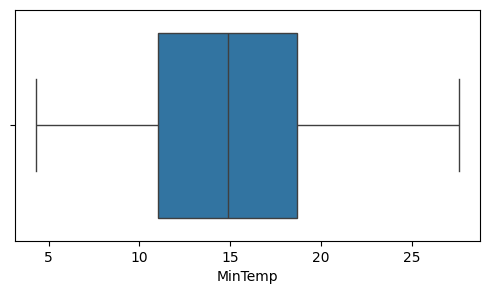

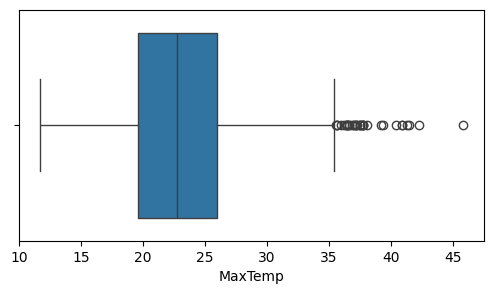

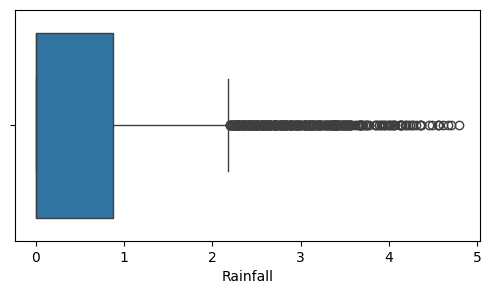

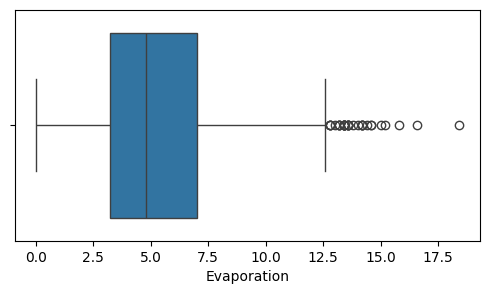

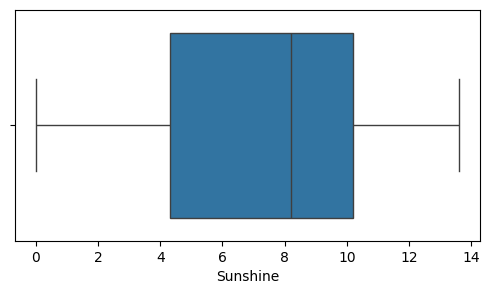

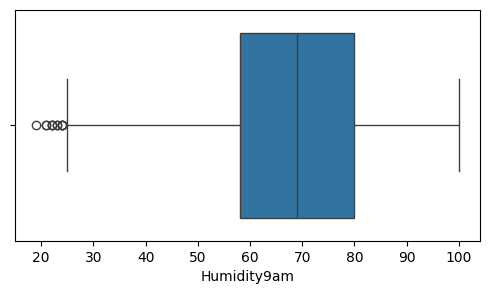

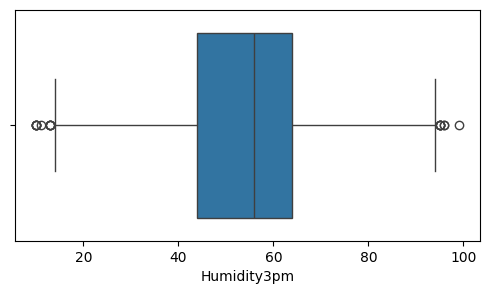

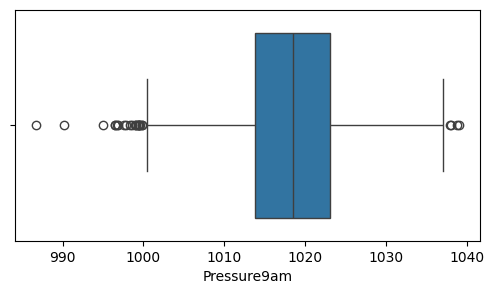

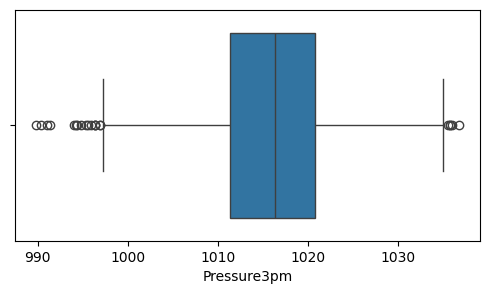

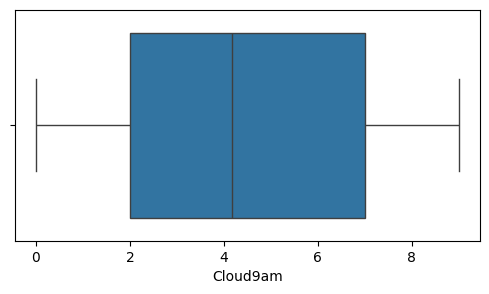

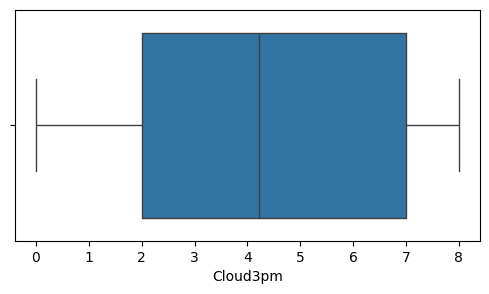

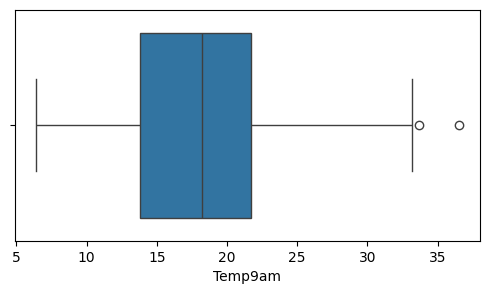

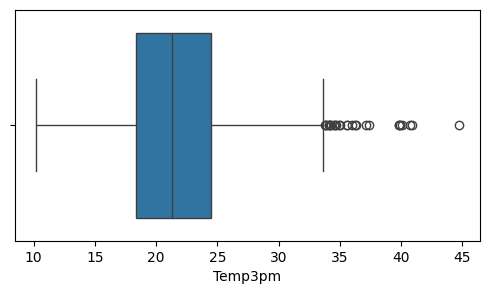

In [15]:
# List of columns to exclude from outlier analysis (categorical and irrelevant for outlier detection)
excluded_columns = ["Month", "RainToday", "RainToday", "RainTomorrow"]

# Looping through columns and plotting boxplot for non-excluded ones, as boxplot helps visualize the spread of data and detect outliers
for col in df.select_dtypes(include = "number").columns:
  if col not in excluded_columns:
    plt.figure(figsize = (6, 3))
    sns.boxplot(x = df[col])
    plt.show()

**Treating Outliers for the above columns using the IQR method**

In [16]:
# Listing all the columns with outliers present in them
cols_with_outliers = ["MaxTemp", "Rainfall", "Evaporation", "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", "Temp9am", "Temp3pm"]

# Calculating the Interquartile Range (IQR) to handle outliers
Q1 = df[cols_with_outliers].quantile(0.25)    # 25th percentile (lower quartile)
Q3 = df[cols_with_outliers].quantile(0.75)    # 75th percentile (upper quartile)

# Interquartile Range
IQR = Q3 - Q1

# Defining the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replacing outliers above and below the defined bounds with the nearest bound
for col in cols_with_outliers:
    df[col] = np.where(df[col] > upper_bound[col], upper_bound[col], df[col])
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col], df[col])

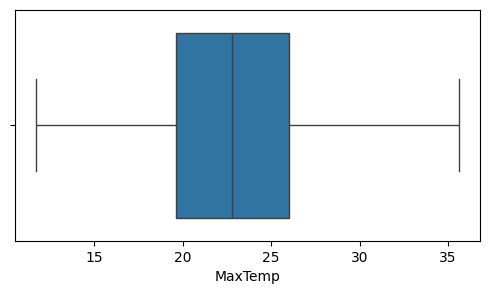

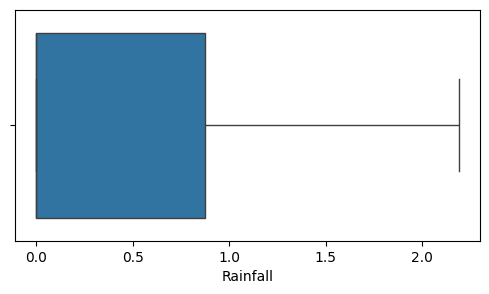

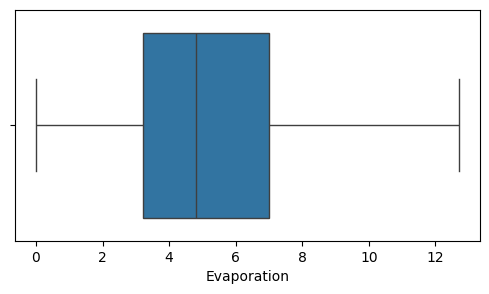

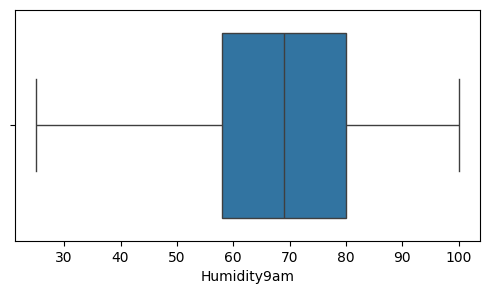

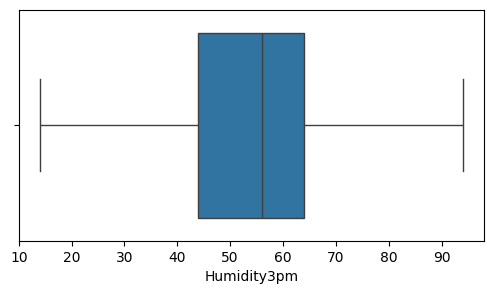

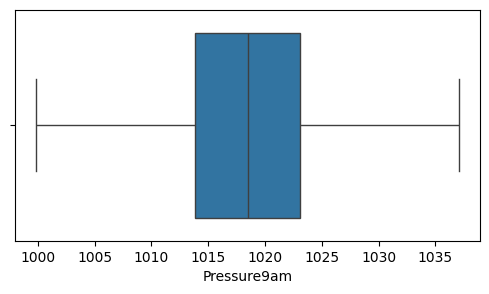

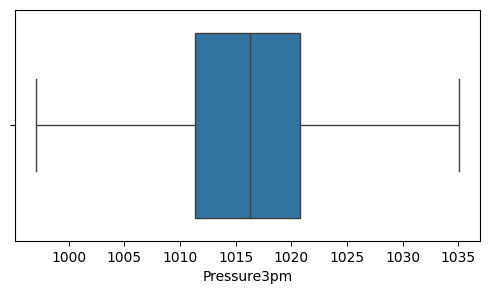

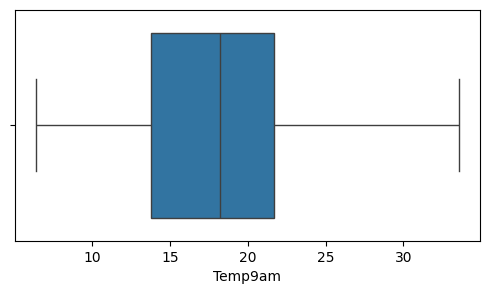

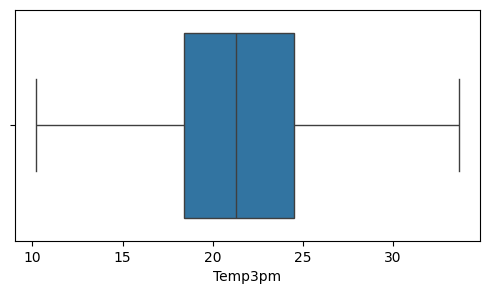

In [17]:
# Rechecking the boxplots after outlier treatment to see if the outliers are removed or not
for col in cols_with_outliers:
  plt.figure(figsize = (6, 3))
  sns.boxplot(x = df[col])
  plt.show()

We can see that we have succesfully removed the outliers from the data.

In [18]:
# Looking at the summary statistics after outliers removal
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month,RainToday,RainTomorrow
count,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000,3337.000000
mean,14.865057,22.977196,0.509000,5.174396,7.179374,68.238300,54.703353,1018.360271,1016.030446,4.181523,4.218660,17.818813,21.510199,6.413545,0.259515,0.259215
std,4.551593,4.409312,0.802818,2.714802,3.801737,15.025889,16.229354,6.946585,6.968893,2.505491,2.409531,4.890985,4.219776,3.397846,0.438434,0.438269
min,4.300000,11.700000,0.000000,0.000000,0.000000,25.000000,14.000000,999.850000,997.050000,0.000000,0.000000,6.400000,10.200000,1.000000,0.000000,0.000000
25%,11.000000,19.600000,0.000000,3.200000,4.300000,58.000000,44.000000,1013.800000,1011.300000,2.000000,2.000000,13.800000,18.400000,3.000000,0.000000,0.000000
50%,14.900000,22.800000,0.000000,4.800000,8.200000,69.000000,56.000000,1018.500000,1016.300000,4.181523,4.218660,18.200000,21.300000,6.000000,0.000000,0.000000
75%,18.700000,26.000000,0.875469,7.000000,10.200000,80.000000,64.000000,1023.100000,1020.800000,7.000000,7.000000,21.700000,24.500000,9.000000,1.000000,1.000000
max,27.600000,35.600000,2.188672,12.700000,13.600000,100.000000,94.000000,1037.050000,1035.050000,9.000000,8.000000,33.550000,33.650000,12.000000,1.000000,1.000000


### **Checking Distribution of Variables**


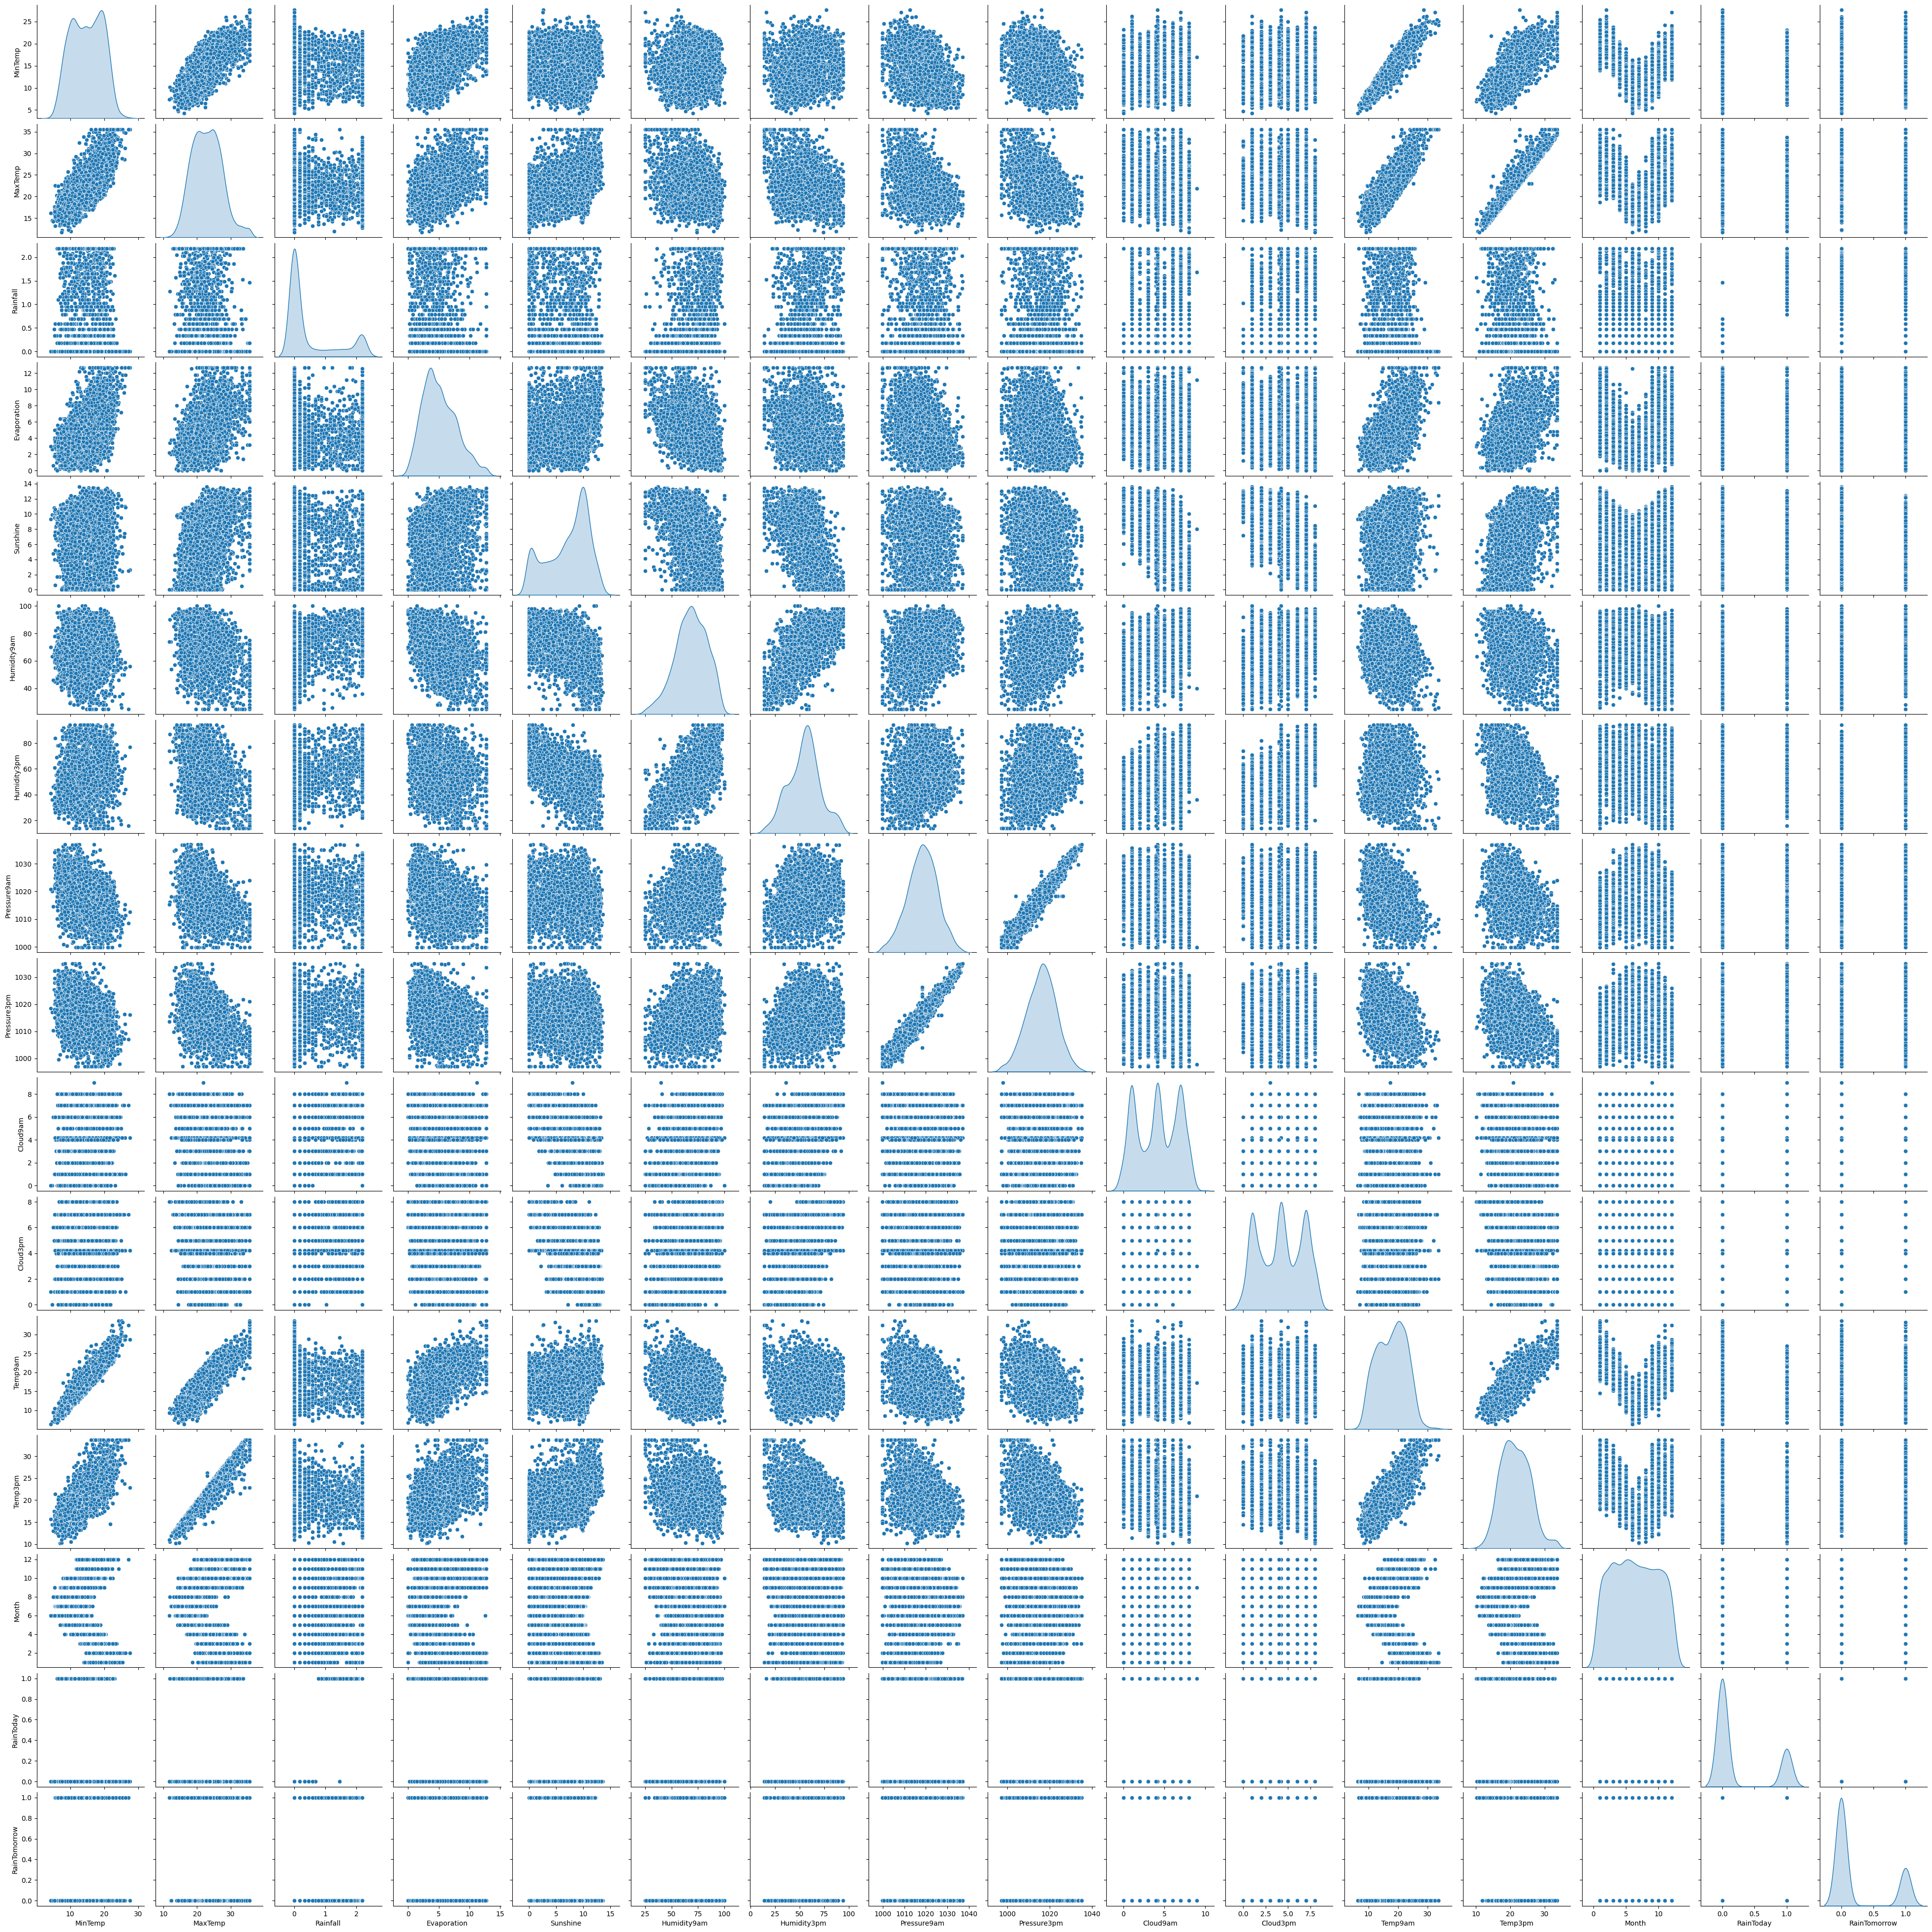

In [19]:
# Plotting pair plot graph for all numerical variables with KDE on the diagonal
sns.pairplot(data = df, diag_kind = "kde")
plt.show()

### **Correlation Analysis**

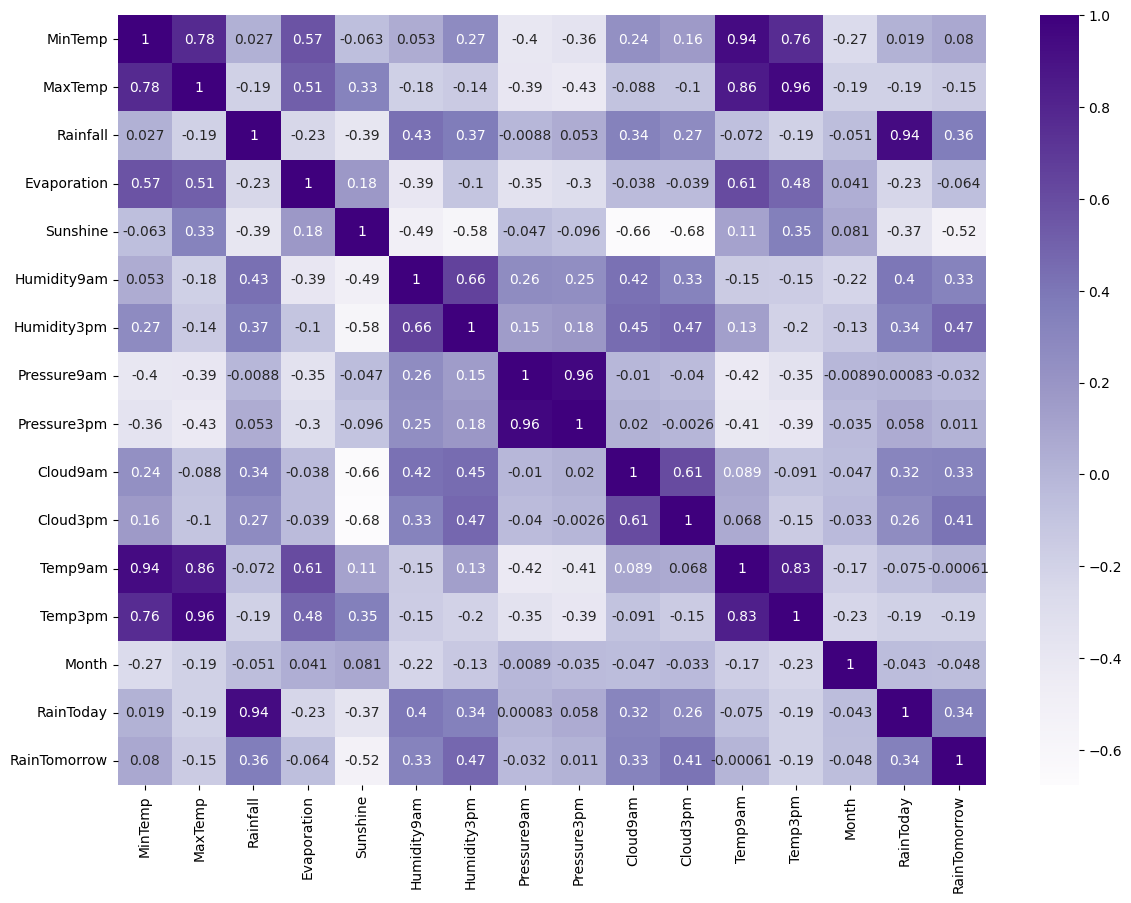

In [20]:
# Plotting a heatmap to visualize the correlation matrix
plt.figure(figsize = (14, 10))

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True, cmap = "Purples")
plt.show()

### **Dropping Columns based on Correlation Analysis**

To address multi-collinearity, we will remove independent variables that have a high correlation with other independent variables. Among the two correlated variables, the one with the lower correlation to the dependent variable will be dropped.

In [21]:
df = df.drop(columns = ["MinTemp", "MaxTemp", "RainToday", "Temp9am", "Pressure3pm"])

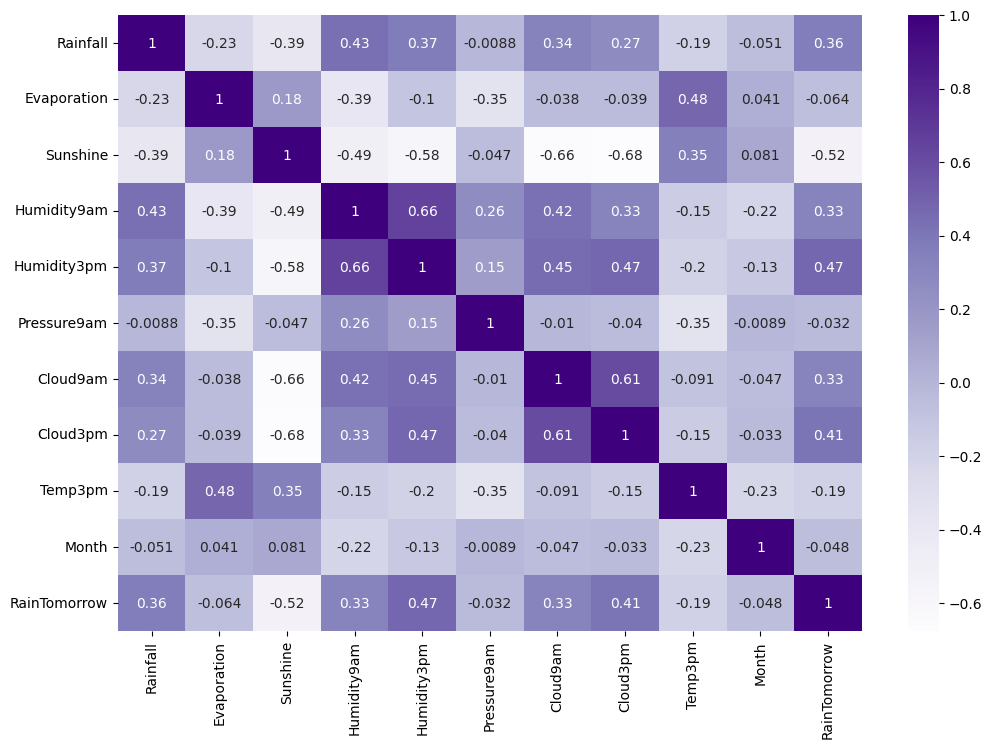

In [22]:
# Plotting the heatmap to visualize the correlation matrix after cleaning the dataset from multi-collinearity
plt.figure(figsize = (12, 8))

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True, cmap = "Purples")
plt.show()

In [23]:
# Viewing the final dataset ready for modeling
df.head()

,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,Temp3pm,Month,RainTomorrow
0,2.188672,6.200000,0.0,92.0,84.0,1017.6,8.0,8.0,20.9,2,1
1,1.945910,3.400000,2.7,83.0,73.0,1017.9,7.0,7.0,24.8,2,1
2,2.028148,2.400000,0.1,88.0,86.0,1016.7,7.0,8.0,23.0,2,1
3,2.188672,2.200000,0.0,83.0,90.0,1014.2,8.0,8.0,20.9,2,1
4,2.188672,5.187432,0.0,88.0,74.0,1008.3,8.0,8.0,25.5,2,1


# **Data Pre-processing**

### **Dependent- Independent Data Split**

In [24]:
# Splitting the data into independent (X) and dependent variable (y)
X = df.loc[:, df.columns != "RainTomorrow"]
y = df["RainTomorrow"]

In [25]:
# Checking the shape of the independent and dependent variables
print(X.shape, y.shape)

(3337, 10) (3337,)


### **Train-Test Split**

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# Splitting the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Checking the shape of train-test splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2669, 10) (668, 10) (2669,) (668,)


# **Logistic Regression**

### **Method 1. Using statsmodels**

In [28]:
import statsmodels.api as sn

By default, `statsmodels` doesn't include the constant term. Thus, we'll first add the constant to our data, and create the $X$ or independent
variables for our model.

In [29]:
# Adding contant to our independent variable X
X_cons = sn.add_constant(X)

In [30]:
# Importing Logistic Regression classifier from statsmodels
import statsmodels.discrete.discrete_model as sm

In [31]:
# Now we will train X and y into our model using logit
logit = sm.Logit(y, X_cons).fit()

Optimization terminated successfully.
         Current function value: 0.385645
         Iterations 7


In [32]:
# Getting the summary of our model
logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           RainTomorrow   No. Observations:                 3337
Model:                          Logit   Df Residuals:                     3326
Method:                           MLE   Df Model:                           10
Date:                Wed, 28 Aug 2024   Pseudo R-squ.:                  0.3261
Time:                        07:01:00   Log-Likelihood:                -1286.9
converged:                       True   LL-Null:                       -1909.5
Covariance Type:            nonrobust   LLR p-value:                2.438e-261
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          30.9880      8.235      3.763      0.000      14.848      47.128
Rainfall        0.5166      0.064      8.043      0.000       0.391       0.643
Evaporation     0.0427      0.023      1.823      0.068      -0.003       0.089
Sunshine       -0.1894      0.022     -8.791      0.000      -0.232      -0.147
Humidity9am     0.0022      0.005      0.414      0.679      -0.008       0.013
Humidity3pm     0.0460      0.005      9.288      0.000       0.036       0.056
Pressure9am    -0.0332      0.008     -4.141      0.000      -0.049      -0.017
Cloud9am       -0.1117      0.030     -3.748      0.000      -0.170      -0.053
Cloud3pm        0.1749      0.031      5.602      0.000       0.114       0.236
Temp3pm        -0.0338      0.017     -1.995      0.046      -0.067      -0.001
Month          -0.0060      0.016     -0.380      0.704      -0.037       0.025
===============================================================================
"""

### **Method 2. Using sklearn**

In [33]:
# Importing Logistic Regression model from sklearn
from sklearn.linear_model import LogisticRegression

In [34]:
# Creating classifier object and fitting data into it
lr_cls = LogisticRegression()
lr_cls.fit(X, y)

LogisticRegression()

Now we will get our coefficients

In [35]:
# beta 0 value
lr_cls.intercept_

array([0.00335649])

In [36]:
# beta 1 value
lr_cls.coef_

array([[ 0.53807435,  0.04293311, -0.18673542, -0.00172601,  0.04719915,
        -0.00331734, -0.11415765,  0.20104251, -0.00805627,  0.00316909]])

**Predicting y values**

In [37]:
y_pred = lr_cls.predict(X)

### **Model Performance**

We will be comparing the performance for all our models using these three performance metrics:

1.   **Confusion Matrix:** This is a table that shows the number of *true positive (TP)*, *true negative (TN)*, *false positive (FP)*, and *false negative (FN)* predictions made by the model. It provides detailed insight into how well our model is classifying each class.

2.   **Accuracy Score:** The ratio of correctly predicted instances *(TP + TN)* to the total instances. It gives an overall performance measure, but it may be less reliable if the classes are imbalanced.

3. **F1 Score:** This is a metric that combines *precision* and *recall* into a single value, offering a balance between the two. It is particularly useful when dealing with imbalanced datasets.

4. **ROC AUC Score:** The area under the ROC curve, which plots the *true positive rate (TPR)* against the *false positive rate (FPR)*. It indicates how well our model distinguishes between the *positive* and *negative classes*.

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score

In [39]:
# Calculating performance metrics
lr_cls_cm = confusion_matrix(y, y_pred)
lr_cls_acc = accuracy_score(y, y_pred)
lr_cls_f1 = f1_score(y, y_pred)
lr_cls_roc = roc_auc_score(y, y_pred)

# Displaying the calculated metrics
print("Confusion Matrix:")
print(lr_cls_cm)
print("\nAccuracy Score:", lr_cls_acc)
print("\nF1 Score:", lr_cls_f1)
print("\nROC AUC Score:", lr_cls_roc)

Confusion Matrix:
[[2296  176]
 [ 375  490]]

Accuracy Score: 0.8348816302067725

F1 Score: 0.6401045068582626

ROC AUC Score: 0.7476382887180351


# **Linear Discriminant Analysis (LDA)**

In [40]:
# Importing LDA classifier from sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [41]:
# Creating classifier object and fitting data into it
lda_cls = LinearDiscriminantAnalysis()
lda_cls.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [42]:
# Calculating the performance scores for the initial LDA model
lda_cls_int_cm = confusion_matrix(y_test, lda_cls.predict(X_test))
lda_cls_int_acc = accuracy_score(y_test, lda_cls.predict(X_test))
lda_cls_int_f1 = f1_score(y_test, lda_cls.predict(X_test))
lda_cls_int_roc = roc_auc_score(y_test, lda_cls.predict(X_test))

# Displaying the initial performance metrics for LDA
print("Inital Confusion Matrix:")
print(lda_cls_int_cm)
print("\nInitial Accuracy Score:", lda_cls_int_acc)
print("\nInitial F1 Score:", lda_cls_int_f1)
print("\nInitial ROC AUC Score:", lda_cls_int_roc)

Inital Confusion Matrix:
[[467  43]
 [ 67  91]]

Initial Accuracy Score: 0.8353293413173652

Initial F1 Score: 0.6232876712328765

Initial ROC AUC Score: 0.7458178207992058


### **Fine Tuning LDA using GridSearchCV**



In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
# Defining the parameter grid for GridSearchCV
param_grid = {"solver": ["svd", "lsqr", "eigen"],
              "shrinkage": [None, "auto", 0.1, 0.5, 0.9]}

# Creating GridSearchCV object and fitting the data
grid_search = GridSearchCV(LinearDiscriminantAnalysis(), param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train, y_train)

# Extracting the best estimator
lda_best = grid_search.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'shrinkage': 'auto', 'solver': 'lsqr'}


In [45]:
# Calculating the performance scores for the optimal LDA model
lda_cls_opt_cm = confusion_matrix(y_test, lda_best.predict(X_test))
lda_cls_opt_acc = accuracy_score(y_test, lda_best.predict(X_test))
lda_cls_opt_f1 = f1_score(y_test, lda_best.predict(X_test))
lda_cls_opt_roc = roc_auc_score(y_test, lda_best.predict(X_test))

# Displaying the tuned performance metrics for LDA
print("Optimized Confusion Matrix:")
print(lda_cls_opt_cm)
print("\nOptimized Accuracy Score:", lda_cls_opt_acc)
print("\nOptimized F1 Score:", lda_cls_opt_f1)
print("\nOptimized ROC AUC Score:", lda_cls_opt_roc)

Optimized Confusion Matrix:
[[468  42]
 [ 66  92]]

Optimized Accuracy Score: 0.8383233532934131

Optimized F1 Score: 0.6301369863013699

Optimized ROC AUC Score: 0.7499627699180937


# **K-Nearest Neighbors (KNN)**

### **Standardizing the Data**

We need to standardize our data before running KNN because it is sensitive to feature scaling.

In [46]:
from sklearn import preprocessing

In [47]:
# Fitting the StandardScaler to the training data and applying the transformation
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train) # Scaled training data

In [48]:
# Fitting the StandardScaler to the test data and applying the transformation
scaler = preprocessing.StandardScaler().fit(X_test)
X_test_s = scaler.transform(X_test) # Scaled test data

**Importing the K-Nearest Neighbors classifier**

In [49]:
from sklearn.neighbors import KNeighborsClassifier

In [50]:
# Defining and fitting a simple KNN model with n_neighbors = 3
knn_cls = KNeighborsClassifier(n_neighbors = 3)
knn_cls.fit(X_train_s, y_train)

KNeighborsClassifier(n_neighbors=3)

In [51]:
# Calculating the performance scores for the initial KNN model
knn_cls_int_cm = confusion_matrix(y_test, knn_cls.predict(X_test_s))
knn_cls_int_acc = accuracy_score(y_test, knn_cls.predict(X_test_s))
knn_cls_int_f1 = f1_score(y_test, knn_cls.predict(X_test_s))
knn_cls_int_roc = roc_auc_score(y_test, knn_cls.predict(X_test_s))

# Displaying the initial performance metrics for KNN
print("Inital Confusion Matrix:")
print(knn_cls_int_cm)
print("\nInitial Accuracy Score:", knn_cls_int_acc)
print("\nInitial F1 Score:", knn_cls_int_f1)
print("\nInitial ROC AUC Score:", knn_cls_int_roc)

Inital Confusion Matrix:
[[456  54]
 [ 81  77]]

Initial Accuracy Score: 0.7979041916167665

Initial F1 Score: 0.5328719723183392

Initial ROC AUC Score: 0.6907297096053612


### **Fine Tuning KNN Classifier using GridSearchCV**

In [52]:
# Defining the parameter grid for GridSearchCV
param_grid = {"n_neighbors": list(range(1, 31))}

# Setting up GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train_s, y_train)

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'n_neighbors': 24}


In [53]:
# Creating the KNN model with the best parameters found
best_knn_cls = grid_search.best_estimator_

# Fitting the optimized KNN model on the training data
best_knn_cls.fit(X_train_s, y_train)

KNeighborsClassifier(n_neighbors=24)

In [54]:
# Calculating the performance scores for the optimal KNN model
knn_cls_opt_cm = confusion_matrix(y_test, best_knn_cls.predict(X_test_s))
knn_cls_opt_acc = accuracy_score(y_test, best_knn_cls.predict(X_test_s))
knn_cls_opt_f1 = f1_score(y_test, best_knn_cls.predict(X_test_s))
knn_cls_opt_roc = roc_auc_score(y_test, best_knn_cls.predict(X_test_s))

# Displaying the tuned performance metrics for KNN
print("Optimized Confusion Matrix:")
print(knn_cls_opt_cm)
print("\nOptimized Accuracy Score:", knn_cls_opt_acc)
print("\nOptimized F1 Score:", knn_cls_opt_f1)
print("\nOptimized ROC AUC Score:", knn_cls_opt_roc)

Optimized Confusion Matrix:
[[482  28]
 [ 86  72]]

Optimized Accuracy Score: 0.8293413173652695

Optimized F1 Score: 0.5581395348837209

Optimized ROC AUC Score: 0.7003971208736659


# **Decision Tree Classifier**

In [55]:
from sklearn import tree

As we don't want to overfit our tree, so we will take the *max_depth* to be 3.

In [56]:
# Creating regressor object and fitting data into it
tree_cls = tree.DecisionTreeClassifier(max_depth = 3)
tree_cls.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [57]:
# Calculating the performance scores for the initial Decision Tree
tree_cls_int_cm = confusion_matrix(y_test, tree_cls.predict(X_test))
tree_cls_int_acc = accuracy_score(y_test, tree_cls.predict(X_test))
tree_cls_int_f1 = f1_score(y_test, tree_cls.predict(X_test))
tree_cls_int_roc = roc_auc_score(y_test, tree_cls.predict(X_test))

# Displaying the initial performance metrics for Decision Tree
print("Inital Confusion Matrix:")
print(tree_cls_int_cm)
print("\nInitial Accuracy Score:", tree_cls_int_acc)
print("\nInitial F1 Score:", tree_cls_int_f1)
print("\nInitial ROC AUC Score:", tree_cls_int_roc)

Inital Confusion Matrix:
[[457  53]
 [ 73  85]]

Initial Accuracy Score: 0.811377245508982

Initial F1 Score: 0.5743243243243243

Initial ROC AUC Score: 0.7170265574584264


### **Visualizing the Decision Tree**

In [58]:
from IPython.display import Image
import pydotplus

In [59]:
# Export the decision tree structure in DOT format using Graphviz
dot_data = tree.export_graphviz(tree_cls, out_file = None, feature_names = X_train.columns, filled = True, rounded = True)

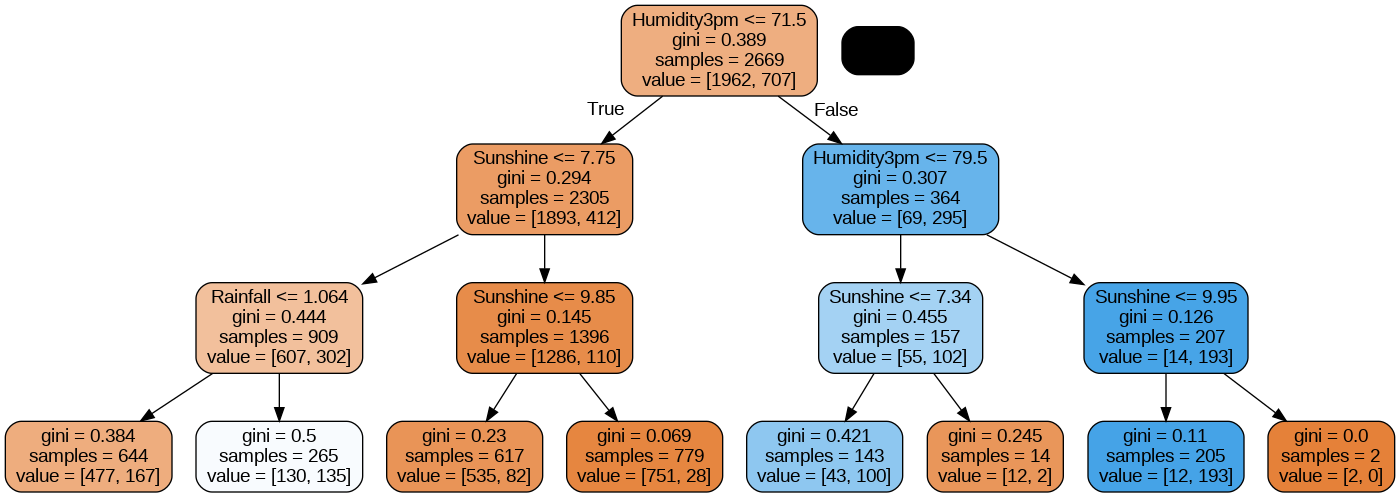

In [60]:
# Displaying decision tree as an image
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

### **Fine Tuning Decision Tree Classifier using GridSearchCV**

We need to keep note that, in order to make our tree interpretable, we should not excede the *max_depth* values beyond 5.

In [61]:
# Creating a default DecisionTreeClassifier object
tree_cls = tree.DecisionTreeClassifier()

In [62]:
# Defining the parameter grid for GridSearchCV
param_grid = {"max_depth": [1, 2, 3, 4, 5], "min_samples_split": [5, 10, 15], "min_samples_leaf": [1, 2, 3, 5]}

# GridSearchCV for Decision Tree
grid_search = GridSearchCV(tree_cls, param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train, y_train)

# Creating the model with the best parameters
tree_cls_best = grid_search.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 5}


In [63]:
# Calculating the performance scores for the optimal Decision Tree
tree_cls_opt_cm = confusion_matrix(y_test, tree_cls_best.predict(X_test))
tree_cls_opt_acc = accuracy_score(y_test, tree_cls_best.predict(X_test))
tree_cls_opt_f1 = f1_score(y_test, tree_cls_best.predict(X_test))
tree_cls_opt_roc = roc_auc_score(y_test, tree_cls_best.predict(X_test))

# Displaying the tuned performance metrics for Decision Tree
print("Optimized Confusion Matrix:")
print(tree_cls_opt_cm)
print("\nOptimized Accuracy Score:", tree_cls_opt_acc)
print("\nOptimized F1 Score:", tree_cls_opt_f1)
print("\nOptimized ROC AUC Score:", tree_cls_opt_roc)

Optimized Confusion Matrix:
[[485  25]
 [ 86  72]]

Optimized Accuracy Score: 0.8338323353293413

Optimized F1 Score: 0.5647058823529412

Optimized ROC AUC Score: 0.7033382973442541


### **Visualizing the Optimized Decision Tree**

In [64]:
# Export the decision tree structure in DOT format using Graphviz
dot_data_optimized = tree.export_graphviz(tree_cls_best, out_file = None, feature_names = X_train.columns, filled = True, rounded = True)

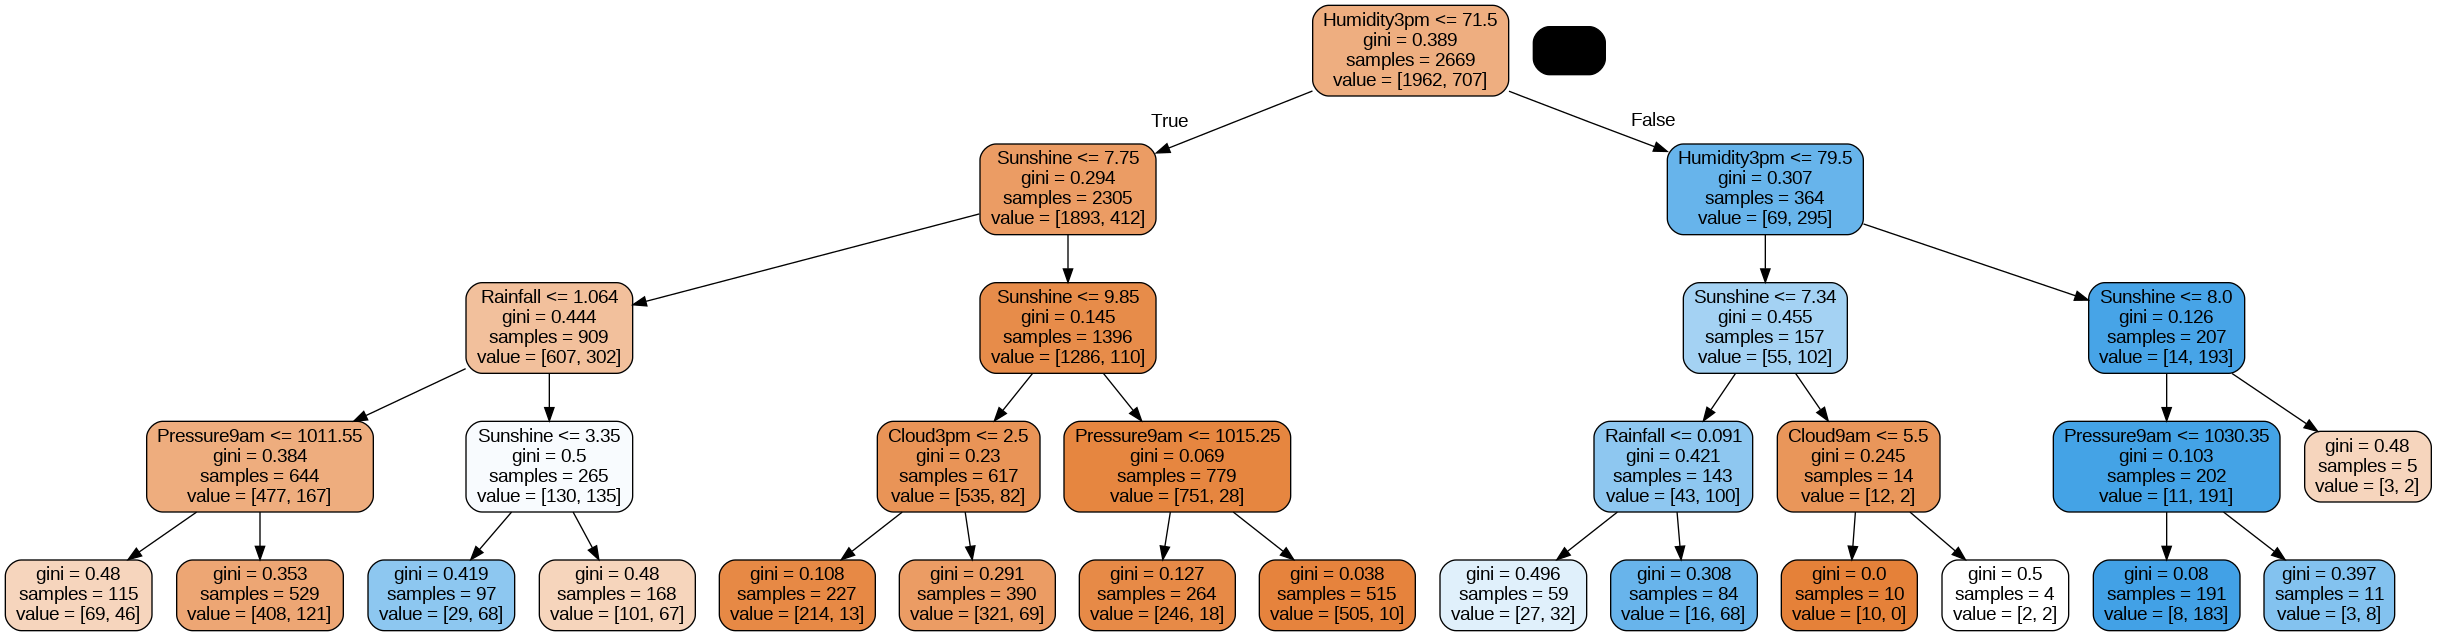

In [65]:
# Displaying decision tree as an image
graph_optimized = pydotplus.graph_from_dot_data(dot_data_optimized)
Image(graph_optimized.create_png())

# **Bagging Classifier**

In [66]:
# Creating a base Decision Tree for the Bagging Classifier
tree_cls = tree.DecisionTreeClassifier()

In [67]:
from sklearn.ensemble import BaggingClassifier

In [68]:
# Basic Bagging Regressor
bag_cls = BaggingClassifier(estimator = tree_cls, n_jobs = -1, random_state = 0)
bag_cls.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_jobs=-1, random_state=0)

In [69]:
# Calculating the performance scores for the initial Bagging model
bsg_cls_int_cm = confusion_matrix(y_test, bag_cls.predict(X_test))
bag_cls_int_acc = accuracy_score(y_test, bag_cls.predict(X_test))
bag_cls_int_f1 = f1_score(y_test, bag_cls.predict(X_test))
bag_cls_int_roc = roc_auc_score(y_test, bag_cls.predict(X_test))

# Displaying the initial performance metrics for Bagging
print("Inital Confusion Matrix:")
print(bsg_cls_int_cm)
print("\nInitial Accuracy Score:", bag_cls_int_acc)
print("\nInitial F1 Score:", bag_cls_int_f1)
print("\nInitial ROC AUC Score:", bag_cls_int_roc)

Inital Confusion Matrix:
[[477  33]
 [ 79  79]]

Initial Accuracy Score: 0.8323353293413174

Initial F1 Score: 0.5851851851851853

Initial ROC AUC Score: 0.7176470588235294


### **Fine Tuning Bagging Classifier using GridSearchCV**

In [70]:
# Defining the parameter grid for GridSearchCV
param_grid = {"n_estimators": [50, 100, 200], "max_samples": [0.8, 0.9]}

# GridSearchCV for Bagging Regressor
grid_search = GridSearchCV(bag_cls, param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train, y_train)

# Creating the model with the best parameters
bag_cls_best = grid_search.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_samples': 0.9, 'n_estimators': 100}


In [71]:
# Calculating the performance scores for the optimal Bagging model
bag_cls_opt_cm = confusion_matrix(y_test, bag_cls_best.predict(X_test))
bag_cls_opt_acc = accuracy_score(y_test, bag_cls_best.predict(X_test))
bag_cls_opt_f1 = f1_score(y_test, bag_cls_best.predict(X_test))
bag_cls_opt_roc = roc_auc_score(y_test, bag_cls_best.predict(X_test))

# Displaying the tuned performance metrics for Bagging
print("Optimized Confusion Matrix:")
print(bag_cls_opt_cm)
print("\nOptimized Accuracy Score:", bag_cls_opt_acc)
print("\nOptimized F1 Score:", bag_cls_opt_f1)
print("\nOptimized ROC AUC Score:", bag_cls_opt_roc)

Optimized Confusion Matrix:
[[472  38]
 [ 68  90]]

Optimized Accuracy Score: 0.8413173652694611

Optimized F1 Score: 0.6293706293706295

Optimized ROC AUC Score: 0.7475552246214943


# **Random Forest Classifier**

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
# Basic Random Forest Classifier
rf_cls = RandomForestClassifier(n_jobs = -1, random_state = 0)
rf_cls.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=0)

In [74]:
# Calculating the performance scores for the initial Random Forest
rf_cls_int_cm = confusion_matrix(y_test, rf_cls.predict(X_test))
rf_cls_int_acc = accuracy_score(y_test, rf_cls.predict(X_test))
rf_cls_int_f1 = f1_score(y_test, rf_cls.predict(X_test))
rf_cls_int_roc = roc_auc_score(y_test, rf_cls.predict(X_test))

# Displaying the initial performance metrics for Random Forest
print("Inital Confusion Matrix:")
print(rf_cls_int_cm)
print("\nInitial Accuracy Score:", rf_cls_int_acc)
print("\nInitial F1 Score:", rf_cls_int_f1)
print("\nInitial ROC AUC Score:", rf_cls_int_roc)

Inital Confusion Matrix:
[[483  27]
 [ 75  83]]

Initial Accuracy Score: 0.8473053892215568

Initial F1 Score: 0.6194029850746269

Initial ROC AUC Score: 0.7361876396128072


### **Fine Tuning Random Forest Classifier using GridSearchCV**

In [75]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [75, 100, 150],
    "max_features": [4, 5],
    "max_depth": [5, 8, 10],
    "min_samples_split": [5, 10]
    }

# GridSearchCV for Random Forest Classifier
grid_search = GridSearchCV(rf_cls, param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train, y_train)

# Creating the model with the best parameters
rf_cls_best = grid_search.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 8, 'max_features': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [76]:
# Calculating the performance scores for the optimal Random Forest
rf_cls_opt_cm = confusion_matrix(y_test, rf_cls_best.predict(X_test))
rf_cls_opt_acc = accuracy_score(y_test, rf_cls_best.predict(X_test))
rf_cls_opt_f1 = f1_score(y_test, rf_cls_best.predict(X_test))
rf_cls_opt_roc = roc_auc_score(y_test, rf_cls_best.predict(X_test))

# Displaying the tuned performance metrics for Random Forest
print("Optimized Confusion Matrix:")
print(rf_cls_opt_cm)
print("\nOptimized Accuracy Score:", rf_cls_opt_acc)
print("\nOptimized F1 Score:", rf_cls_opt_f1)
print("\nOptimized ROC AUC Score:", rf_cls_opt_roc)

Optimized Confusion Matrix:
[[484  26]
 [ 79  79]]

Optimized Accuracy Score: 0.842814371257485

Optimized F1 Score: 0.6007604562737643

Optimized ROC AUC Score: 0.7245098039215685


# **Gradient Boosting**

In [77]:
from sklearn.ensemble import GradientBoostingClassifier

In [78]:
# Basic Gradient Boosting Regressor
gb_cls = GradientBoostingClassifier()
gb_cls.fit(X_train, y_train)

GradientBoostingClassifier()

In [79]:
# Calculating the performance scores for the initial Gradient Boost
gb_cls_int_cm = confusion_matrix(y_test, gb_cls.predict(X_test))
gb_cls_int_acc = accuracy_score(y_test, gb_cls.predict(X_test))
gb_cls_int_f1 = f1_score(y_test, gb_cls.predict(X_test))
gb_cls_int_roc = roc_auc_score(y_test, gb_cls.predict(X_test))

# Displaying the initial performance metrics for Gradient Boost
print("Inital Confusion Matrix:")
print(gb_cls_int_cm)
print("\nInitial Accuracy Score:", gb_cls_int_acc)
print("\nInitial F1 Score:", gb_cls_int_f1)
print("\nInitial ROC AUC Score:", gb_cls_int_roc)

Inital Confusion Matrix:
[[483  27]
 [ 80  78]]

Initial Accuracy Score: 0.8398203592814372

Initial F1 Score: 0.5931558935361217

Initial ROC AUC Score: 0.7203648548026805


### **Fine Tuning Gradient Boost using GridSearchCV**

In [80]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [70, 100],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 4],
    "subsample": [0.8, 0.9]
    }

# GridSearchCV for Gradient Boosting Classifier
grid_search = GridSearchCV(gb_cls, param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train, y_train)

# Creating the model with the best parameters
gb_cls_best = grid_search.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 70, 'subsample': 0.8}


In [81]:
# Calculating the performance scores for the optimal Gradient Boost model
gb_cls_opt_cm = confusion_matrix(y_test, gb_cls_best.predict(X_test))
gb_cls_opt_acc = accuracy_score(y_test, gb_cls_best.predict(X_test))
gb_cls_opt_f1 = f1_score(y_test, gb_cls_best.predict(X_test))
gb_cls_opt_roc = roc_auc_score(y_test, gb_cls_best.predict(X_test))

# Displaying the tuned performance metrics for Gradient Boost model
print("Optimized Confusion Matrix:")
print(gb_cls_opt_cm)
print("\nOptimized Accuracy Score:", gb_cls_opt_acc)
print("\nOptimized F1 Score:", gb_cls_opt_f1)
print("\nOptimized ROC AUC Score:", gb_cls_opt_roc)

Optimized Confusion Matrix:
[[483  27]
 [ 77  81]]

Optimized Accuracy Score: 0.844311377245509

Optimized F1 Score: 0.6090225563909774

Optimized ROC AUC Score: 0.7298585256887565


# **Ada Boost**

In [82]:
from sklearn.ensemble import AdaBoostClassifier

In [83]:
# Basic AdaBoost Regressor
ada_cls = AdaBoostClassifier()
ada_cls.fit(X_train, y_train)

AdaBoostClassifier()

In [84]:
# Calculating the performance scores for the initial Ada Boost
ada_cls_int_cm = confusion_matrix(y_test, ada_cls.predict(X_test))
ada_cls_int_acc = accuracy_score(y_test, ada_cls.predict(X_test))
ada_cls_int_f1 = f1_score(y_test, ada_cls.predict(X_test))
ada_cls_int_roc = roc_auc_score(y_test, ada_cls.predict(X_test))

# Displaying the initial performance metrics for Ada Boost
print("Inital Confusion Matrix:")
print(ada_cls_int_cm)
print("\nInitial Accuracy Score:", ada_cls_int_acc)
print("\nInitial F1 Score:", ada_cls_int_f1)
print("\nInitial ROC AUC Score:", ada_cls_int_roc)

Inital Confusion Matrix:
[[476  34]
 [ 78  80]]

Initial Accuracy Score: 0.8323353293413174

Initial F1 Score: 0.5882352941176471

Initial ROC AUC Score: 0.719831223628692


### **Fine Tuning Ada Boost using GridSearchCV**

In [85]:
rf_clf = RandomForestClassifier(n_jobs = -1, random_state = 0)

# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [100, 150, 200],
    "max_features": [3, 4],
    "max_depth": [4, 5, 6]
    }

# GridSearchCV for Ada Boosting Classifier
grid_search_ada = GridSearchCV(rf_cls, param_grid, cv = 5, scoring = "accuracy")
grid_search_ada.fit(X_train, y_train)

# Creating the model with the best parameters
ada_cls_best = grid_search_ada.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search_ada.best_params_)

Best Parameters: {'max_depth': 5, 'max_features': 3, 'n_estimators': 200}


In [86]:
# Calculating the performance scores for the optimal Ada Boost model
ada_cls_opt_cm = confusion_matrix(y_test, ada_cls_best.predict(X_test))
ada_cls_opt_acc = accuracy_score(y_test, ada_cls_best.predict(X_test))
ada_cls_opt_f1 = f1_score(y_test, ada_cls_best.predict(X_test))
ada_cls_opt_roc = roc_auc_score(y_test, ada_cls_best.predict(X_test))

# Displaying the tuned performance metrics for Ada Boost model
print("Optimized Confusion Matrix:")
print(ada_cls_opt_cm)
print("\nOptimized Accuracy Score:", ada_cls_opt_acc)
print("\nOptimized F1 Score:", ada_cls_opt_f1)
print("\nOptimized ROC AUC Score:", ada_cls_opt_roc)

Optimized Confusion Matrix:
[[491  19]
 [ 82  76]]

Optimized Accuracy Score: 0.8488023952095808

Optimized F1 Score: 0.6007905138339921

Optimized ROC AUC Score: 0.7218788781335319


# **XG Boost**

In [87]:
import xgboost as xgb

In [88]:
# Basic XGBoost Classifier
xgb_cls = xgb.XGBClassifier(n_jobs = -1, random_state = 0)
xgb_cls.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=0, ...)

In [89]:
# Calculating the performance scores for the initial XG Boost
xgb_cls_int_cm = confusion_matrix(y_test, xgb_cls.predict(X_test))
xgb_cls_int_acc = accuracy_score(y_test, xgb_cls.predict(X_test))
xgb_cls_int_f1 = f1_score(y_test, xgb_cls.predict(X_test))
xgb_cls_int_roc = roc_auc_score(y_test, xgb_cls.predict(X_test))

# Displaying the initial performance metrics for XG Boost
print("Inital Confusion Matrix:")
print(xgb_cls_int_cm)
print("\nInitial Accuracy Score:", xgb_cls_int_acc)
print("\nInitial F1 Score:", xgb_cls_int_f1)
print("\nInitial ROC AUC Score:", xgb_cls_int_roc)

Inital Confusion Matrix:
[[472  38]
 [ 71  87]]

Initial Accuracy Score: 0.8368263473053892

Initial F1 Score: 0.6148409893992933

Initial ROC AUC Score: 0.7380615537354183


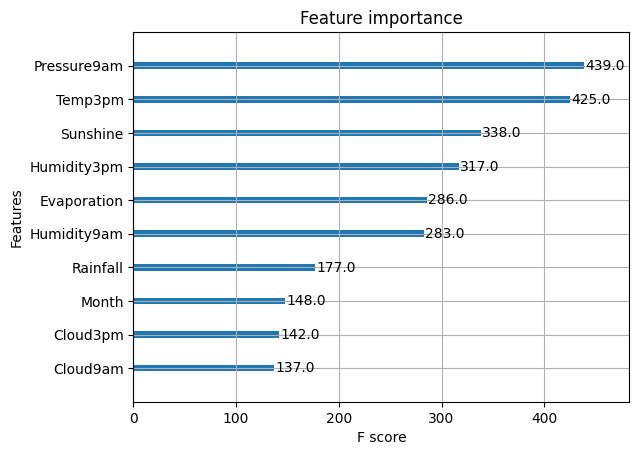

In [90]:
# Plotting feature importance for the trained XG Boost model
xgb.plot_importance(xgb_cls)
plt.show()

*Pressure9am* and *Temp3pm* are the most important features, while *Cloud9am* and *Cloud3pm* are the least important for the model's predictions.

Prioritizing key features can improve understanding and model performance.

### **Fine Tuning XG Boost using GridSearchCV**

In [91]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [75, 100, 250],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "gamma": [0.1, 0.2],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_alpha": [1e-2, 0.1, 1]
    }

# GridSearchCV for XG Boost Classifier
grid_search = GridSearchCV(xgb_cls, param_grid, cv = 5, scoring = "accuracy")
grid_search.fit(X_train, y_train)

# Creating the model with the best parameters
xgb_cls_best = grid_search.best_estimator_

# Displaying the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 250, 'reg_alpha': 0.1, 'subsample': 0.8}


In [92]:
# Calculating the performance scores for the optimal XG Boost model
xgb_cls_opt_cm = confusion_matrix(y_test, xgb_cls_best.predict(X_test))
xgb_cls_opt_acc = accuracy_score(y_test, xgb_cls_best.predict(X_test))
xgb_cls_opt_f1 = f1_score(y_test, xgb_cls_best.predict(X_test))
xgb_cls_opt_roc = roc_auc_score(y_test, xgb_cls_best.predict(X_test))

# Displaying the tuned performance metrics for XG Boost model
print("Optimized Confusion Matrix:")
print(xgb_cls_opt_cm)
print("\nOptimized Accuracy Score:", xgb_cls_opt_acc)
print("\nOptimized F1 Score:", xgb_cls_opt_f1)
print("\nOptimized ROC AUC Score:", xgb_cls_opt_roc)

Optimized Confusion Matrix:
[[492  18]
 [ 82  76]]

Optimized Accuracy Score: 0.8502994011976048

Optimized F1 Score: 0.6031746031746031

Optimized ROC AUC Score: 0.7228592702903947


# **Comparing Performance of all the Models**

In [93]:
# Models without Tuned Performance
models = ["Logistic Regression", "LDA", "KNN", "Decision Tree", "Bagging",
          "Random Forest", "Gradient Boosting", "Ada Boost", "XG Boost"]

# Models with Tuning Performance
tuned_models = ["LDA", "KNN", "Decision Tree", "Bagging", "Random Forest",
                "Gradient Boosting", "Ada Boost", "XG Boost"]

In [94]:
# Accuracy Scores for basic models
acc_basic = [lr_cls_acc, lda_cls_int_acc, knn_cls_int_acc, tree_cls_int_acc, bag_cls_int_acc,
            rf_cls_int_acc, gb_cls_int_acc, ada_cls_int_acc, xgb_cls_int_acc]

# Accuracy Scores for tuned models
acc_tuned = [lda_cls_opt_acc, knn_cls_opt_acc, tree_cls_opt_acc, bag_cls_opt_acc,
            rf_cls_opt_acc, gb_cls_opt_acc, ada_cls_opt_acc, xgb_cls_opt_acc]

### **Plotting Comparison between the Basic Models based on Accuracy Score**

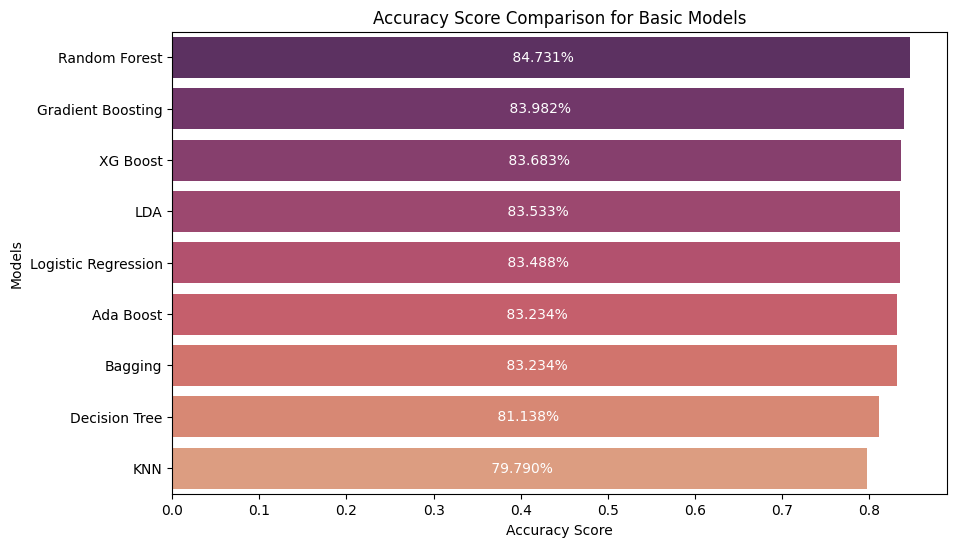

In [95]:
# Sorting models and accuracy scores in decreasing order
sorted_indices = np.argsort(acc_basic)[:: -1]
sorted_models = [models[i] for i in sorted_indices]
sorted_acc_basic = [acc_basic[i] for i in sorted_indices]

# Plotting the bar chart with labels
plt.figure(figsize = (10, 6))
sns.barplot(x = sorted_acc_basic, y = sorted_models, palette = "flare_r")
plt.title("Accuracy Score Comparison for Basic Models")
plt.xlabel("Accuracy Score")
plt.ylabel("Models")

# Adding the accuracy score labels
for i, acc in enumerate(sorted_acc_basic):
    plt.text(acc / 2, i, f"{acc * 100 : .3f}%", color = "white", ha = "center", va = "center")

plt.show()

**Summary:**

The chart shows that the **Random Forest** model has the highest accuracy score of **84.731%**, making it the best performer among the basic models tested.

**Gradient Boosting** and **XGBoost** also perform well, with accuracy scores **83.982%** and **83.683%** respectively.

**KNN** has the lowest accuracy at **79.790%**, suggesting it is the least effective model in this comparison.

### **Plotting Comparison between the Tuned Models based on Accuracy Score**

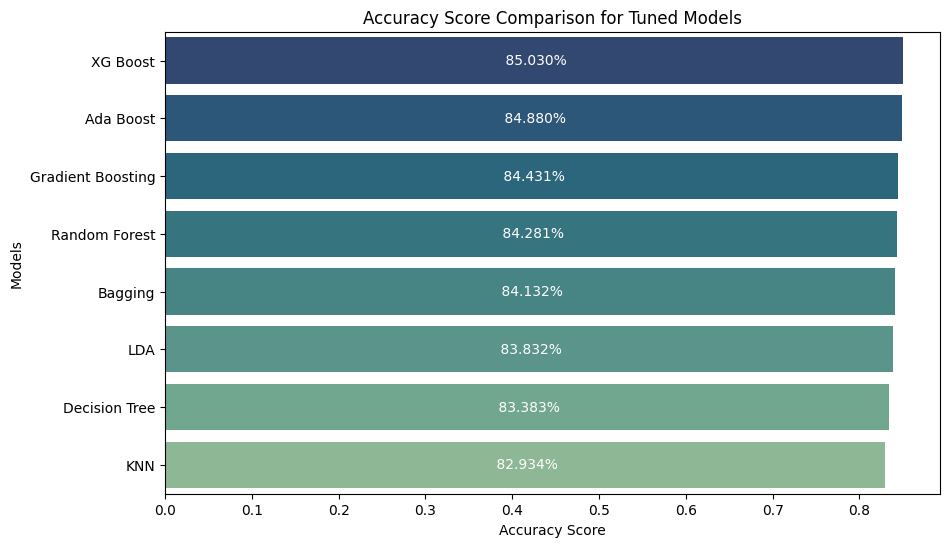

In [96]:
# Sorting tuned_models and accuracy scores in decreasing order
sorted_indices = np.argsort(acc_tuned)[:: -1]
sorted_models = [tuned_models[i] for i in sorted_indices]
sorted_acc_tuned = [acc_tuned[i] for i in sorted_indices]

# Plotting the bar chart with labels
plt.figure(figsize = (10, 6))
sns.barplot(x = sorted_acc_tuned, y = sorted_models, palette = "crest_r")
plt.title("Accuracy Score Comparison for Tuned Models")
plt.xlabel("Accuracy Score")
plt.ylabel("Models")

# Adding the accuracy score labels
for i, acc in enumerate(sorted_acc_tuned):
    plt.text(acc / 2, i, f"{acc * 100 : .3f}%", color = "white", ha = "center", va = "center")

plt.show()

**Summary:**

The chart shows that after tuning, **XGBoost** achieves the highest accuracy of **85.030%**, making it the top performer among the models.

**AdaBoost** and **Gradient Boosting** also show strong performance with accuracy scores **84.880%** and **84.431%** respectively.

**KNN**, although improved, remains the lowest at **82.934%**, indicating it still lags behind other models even after tuning.